In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [125]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [13]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [115]:
odir = "ps_data"
with open(f"{odir}/ics/TNG300-3/test14.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.035287552


In [15]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/test4.pickle", "rb") as f:
    Pk2 = pickle.load(f)
    
print("shotnoise", Pk2.attrs["shotnoise"])

shotnoise 0.035287552


In [73]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap0/test1.pickle", "rb") as f:
    Pk2 = pickle.load(f)
    
print("shotnoise", Pk2.attrs["shotnoise"])

shotnoise 0.035287552


In [64]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15-only')

In [60]:
cosmo = cosmology.setCosmology('planck15')

In [50]:
print(cosmo)

Cosmology "planck15-only" 
    flat = True, Om0 = 0.3080, Ode0 = 0.6919, Ob0 = 0.0484, H0 = 67.81, sigma8 = 0.8149, ns = 0.9677
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


In [61]:
print(cosmo)

Cosmology "planck15" 
    flat = True, Om0 = 0.3089, Ode0 = 0.6910, Ob0 = 0.0486, H0 = 67.74, sigma8 = 0.8159, ns = 0.9667
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


In [77]:
z = 1.5
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)

In [78]:
cosmo = cosmology.setCosmology('planck15-only')
z = 1.5
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)
growth_factor = (D15/D127)**2
print(growth_factor)

2373.1849376076734


In [79]:
cosmo = cosmology.setCosmology('planck15')
z = 20
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)
growth_factor = (D15/D127)**2
print(growth_factor)

35.639600113129454


In [19]:
Pk_lin_colossus = cosmo.matterPowerSpectrum(ks, 1.5)
Pk_lin_colossus_ic_camb = cosmo.matterPowerSpectrum(ks, 127)

NameError: name 'ks' is not defined

In [21]:
iend = 190
ks = Pk2['k'][:iend]

coef = ks**3 / (2 * np.pi **2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


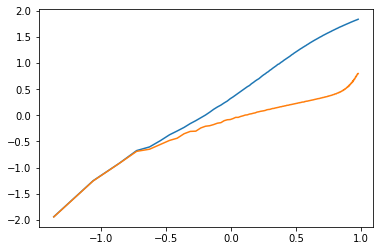

In [22]:
plt.plot(np.log10(ks), np.log10(coef * Pk2["power"][:iend]), label="TNG total")
#plt.plot(np.log10(ks), np.log10(coef * (Pk2["power"][:iend]-Pk2.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]*growth_factor), label="TNG total")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 1.1)

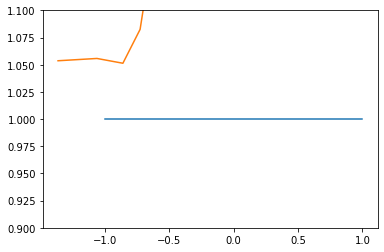

In [39]:
plt.plot([-1,1], [1,1])
plt.plot(np.log10(ks), Pk2["power"][:iend]/(Pk_ic["power"][:iend]*growth_factor))
plt.ylim(0.9,1.1)

In [84]:

Pk_lin_colossus_ic_98 = cosmo.matterPowerSpectrum(ks, 127, model="eisenstein98")
Pk_lin_colossus_ic_camb = cosmo.matterPowerSpectrum(ks, 127)

In [121]:
Pk_lin_colossus_ic_98_zb = cosmo.matterPowerSpectrum(ks, 127, model="eisenstein98_zb")


In [122]:
Pk_colossus_15 = cosmo.matterPowerSpectrum(ks, 20, model="eisenstein98")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


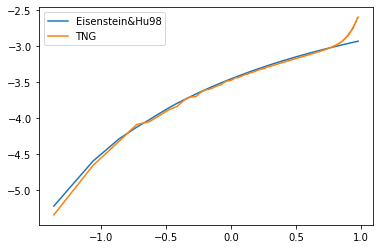

In [72]:

#plt.plot(np.log10(ks), np.log10(coef * (Pk2["power"][:iend]-Pk2.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * Pk_lin_colossus_ic_98[:iend]), label="Eisenstein&Hu98")
plt.plot(np.log10(ks), np.log10(coef * Pk_ic["power"][:iend]), label="TNG")
plt.legend()

NameError: name 'Pk_lin_colossus_ic_98' is not defined

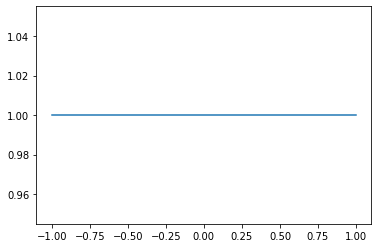

In [25]:
plt.plot([-1,1], [1,1])
plt.plot(np.log10(ks),(Pk_ic["power"][:iend])/Pk_lin_colossus_ic_98, label="Eisenstein98")
plt.ylim(0.8,1.2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


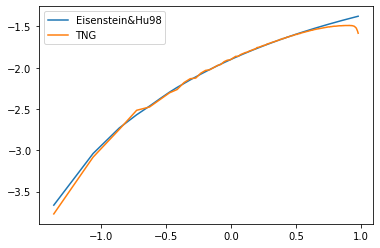

In [75]:
plt.plot(np.log10(ks), np.log10(coef * Pk_colossus_15[:iend]), label="Eisenstein&Hu98")
plt.plot(np.log10(ks), np.log10(coef * Pk2["power"][:iend]), label="TNG")
plt.legend()

In [46]:
d = Pk2["power"].real[0]/Pk_ic["power"].real[0]
print(d)

2500.504627273206


In [48]:
Pk_ic["power"].real[0]

1.1054650820218601

In [47]:
d = Pk2["power"].real[1]/Pk_ic["power"].real[1]
print(d)

2505.5114836457883


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 1.4)

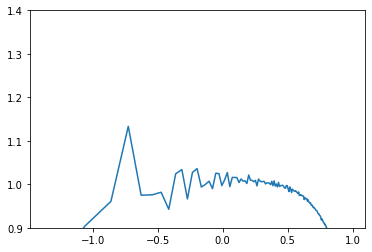

In [123]:
plt.plot(np.log10(ks),  Pk2["power"][:iend]/Pk_colossus_15[:iend])

#plt.plot(np.log10(ks), Pk2["power"][:iend]/(Pk_ic["power"][:iend]*d))

#plt.plot(np.log10(ks), (Pk_ic["power"][:iend]*d)/Pk_colossus_15[:iend])
plt.ylim(0.9,1.4)
#plt.ylim(0,2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

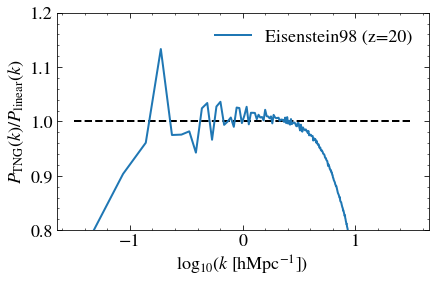

In [127]:
plt.plot([-1.5,1.5], [1,1], c="k", linestyle="dashed")
plt.plot(np.log10(ks), Pk2["power"][:iend]/Pk_colossus_15[:iend], label="Eisenstein98 (z=20)")

plt.ylim(0.8,1.2)
plt.legend()
plt.ylabel(r"$P_{\mathrm{TNG}}(k)/P_{\mathrm{linear}}(k)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 1.4)

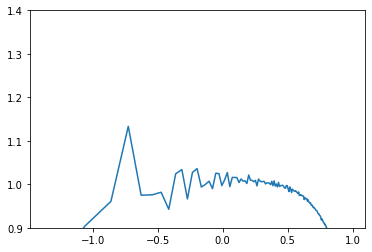

In [120]:
plt.plot(np.log10(ks),  Pk2["power"][:iend]/Pk_colossus_15[:iend])

plt.plot(np.log10(ks), Pk2["power"][:iend]/(Pk_ic["power"][:iend]*d))

plt.plot(np.log10(ks), (Pk_ic["power"][:iend]*d)/Pk_colossus_15[:iend])
plt.ylim(0.9,1.4)
#plt.ylim(0,2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.9, 1.4)

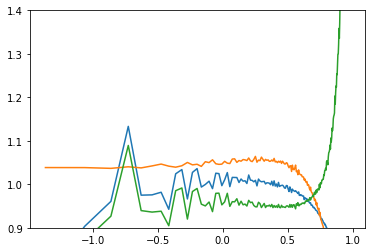

In [116]:
plt.plot(np.log10(ks),  Pk2["power"][:iend]/Pk_colossus_15[:iend])

plt.plot(np.log10(ks), Pk2["power"][:iend]/(Pk_ic["power"][:iend]*growth_factor))

plt.plot(np.log10(ks), (Pk_ic["power"][:iend]*growth_factor)/Pk_colossus_15[:iend])
plt.ylim(0.9,1.4)
#plt.ylim(0,2)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(-0.5, 0.5)

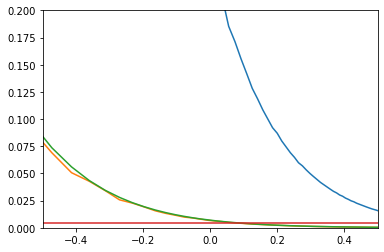

In [114]:
plt.plot(np.log10(ks), Pk2["power"][:iend])
plt.plot(np.log10(ks), (Pk_ic["power"][:iend]))
plt.plot(np.log10(ks), Pk_lin_colossus_ic_98)
plt.plot([np.log10(ks[0]), np.log10(ks[-1])], [Pk_ic.attrs["shotnoise"],Pk_ic.attrs["shotnoise"]])
plt.ylim(0,0.2)
plt.xlim(-0.5,0.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.0, 0.5)

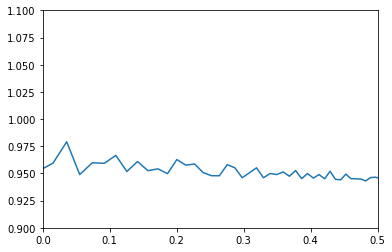

In [113]:
plt.plot(np.log10(ks), Pk_ic["power"][:iend]/Pk_lin_colossus_ic_98)
plt.ylim(0.9,1.1)
plt.xlim(0,0.5)

In [51]:
k_eagle1, pk_eagle1 = np.loadtxt("EAGLE_ics.txt", unpack = True)

In [ ]:
h_eagle = 0.6777

In [56]:
mask = (k_eagle > -2) & (k_eagle < 2)
k_eagle, pk_eagle = k_eagle1[mask], pk_eagle[mask]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 1401 but corresponding boolean dimension is 399

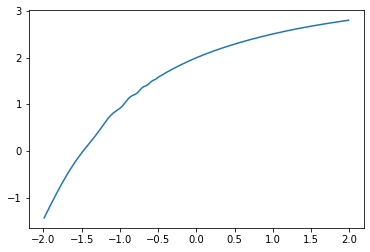

In [57]:
plt.plot(k_eagle, pk_eagle)

In [58]:
import camb
from camb import model, initialpower

In [ ]:
pars = camb.read_ini('Planck2018_ini.txt')